# Numerical controls and robustness checks

This notebook exposes the cutoff, initial-radius, temporal-memory, tracer-number, roughness, finite-lag, interpolation, and MEE-tolerance checks used in the revision and referee response.

In [1]:
from pathlib import Path
import json, subprocess, sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('Repository root:', ROOT)

REANALYZE = False

Repository root: /mnt/data/work_release_v3/LagrangianEllipsoid_Corrected_Release_v3/2_github_repository


In [2]:
if REANALYZE:
    subprocess.run([sys.executable, str(ROOT/'scripts/analyze_ensembles.py')], cwd=ROOT, check=True)
    subprocess.run([sys.executable, str(ROOT/'scripts/numerical_audit.py')], cwd=ROOT, check=True)
    print('Controls regenerated.')
else:
    print('Using frozen control summaries.')

Using frozen control summaries.


In [3]:
analysis = json.loads((ROOT/'data/results/phase3B_analysis_summary.json').read_text())
audit = json.loads((ROOT/'data/results/numerical_audit_b.json').read_text())
print('Inventory:')
print(json.dumps(analysis['inventory'], indent=2))
print('\nNumerical audit:')
print(json.dumps(audit, indent=2))

Inventory:
{
  "B1_k192": 24,
  "roughness": {
    "0.25": 12,
    "0.3333333333333333": 12,
    "0.5": 10,
    "0.6666666666666666": 10
  },
  "k64": 8,
  "r0half": 8,
  "r0double": 8,
  "memconst": 8,
  "memshort": 8,
  "nestedN": 6
}

Numerical audit:
{
  "Kmax": 192,
  "ngrid": 768,
  "interpolation_relative_rms_mean": 0.003308833394432434,
  "interpolation_relative_rms_max": 0.003665141759907475,
  "mee_comparisons": 20,
  "mee_sigma_abs_mean": 0.010705968662029133,
  "mee_sigma_abs_max": 0.03957389045895099,
  "mee_r_rel_mean": 0.005397213059894657,
  "mee_r_rel_max": 0.007025985543178681,
  "mee_center_abs_max": 0.011958674810457353
}


In [4]:
print('\nCutoff control')
for k,v in analysis['controls']['cutoff'].items(): print(k, 'MEE slope=', round(v['beta_mee_mean'],3), '+/-', round(v['beta_mee_sem'],3))
print('\nInitial-radius control')
for k,v in analysis['controls']['initial_radius'].items(): print(k, 'MEE slope=', round(v['beta_mee_mean'],3), '+/-', round(v['beta_mee_sem'],3))
print('\nMemory control')
for k,v in analysis['controls']['memory'].items(): print(k, 'MEE slope=', round(v['beta_mee_mean'],3), '+/-', round(v['beta_mee_sem'],3))


Cutoff control
K64 MEE slope= -0.361 +/- 0.211
K128 MEE slope= 0.252 +/- 0.167
K192 MEE slope= 0.133 +/- 0.106

Initial-radius control
r0_half_uv MEE slope= -0.463 +/- 0.276
r0_one_uv MEE slope= -0.134 +/- 0.255
r0_two_uv MEE slope= -0.047 +/- 0.259

Memory control
turnover MEE slope= 0.252 +/- 0.167
constant MEE slope= -0.151 +/- 0.237
short MEE slope= 0.406 +/- 0.373


In [5]:
print('Particle-number control')
for n,v in analysis['controls']['particle_number'].items():
    print(n, 'sigma_MEE=', round(v['mee_mean'],3), 'delta_rho=', round(v['delta_rho_mean'],3))
print('\nSupport diagnostics:')
print(json.dumps(analysis['support'], indent=2))

Particle-number control
100 sigma_MEE= 0.959 delta_rho= 0.203
300 sigma_MEE= 0.903 delta_rho= 0.243
1000 sigma_MEE= 0.913 delta_rho= 0.309

Support diagnostics:
{
  "support_to_bulk_error_ratio_mean": 1.526438762642056,
  "support_to_bulk_error_ratio_sem": 0.029789782842394197,
  "turnover_mean": 0.6629108404970782,
  "turnover_sem": 0.009242563955291137,
  "boundary_count_mean": 1.2857553845846692,
  "boundary_count_sem": 0.01457743683879572,
  "nonaffinity_mean": 0.5677663736031909,
  "nonaffinity_sem": 0.008672572800359699,
  "Renv_switch_mean": -0.12314069110701183,
  "Renv_switch_sem": 0.04102458063483995,
  "Renv_persistent_mean": -0.05256650909978768,
  "Renv_persistent_sem": 0.09866864383633013,
  "corr_Renv_turnover_mean": -0.028440110063185114,
  "corr_Renv_turnover_sem": 0.03433777789311971,
  "corr_Renv_nonaffinity_mean": -0.003733399072049876,
  "corr_Renv_nonaffinity_sem": 0.046179044112773904
}


B3_MEE_robustness.png


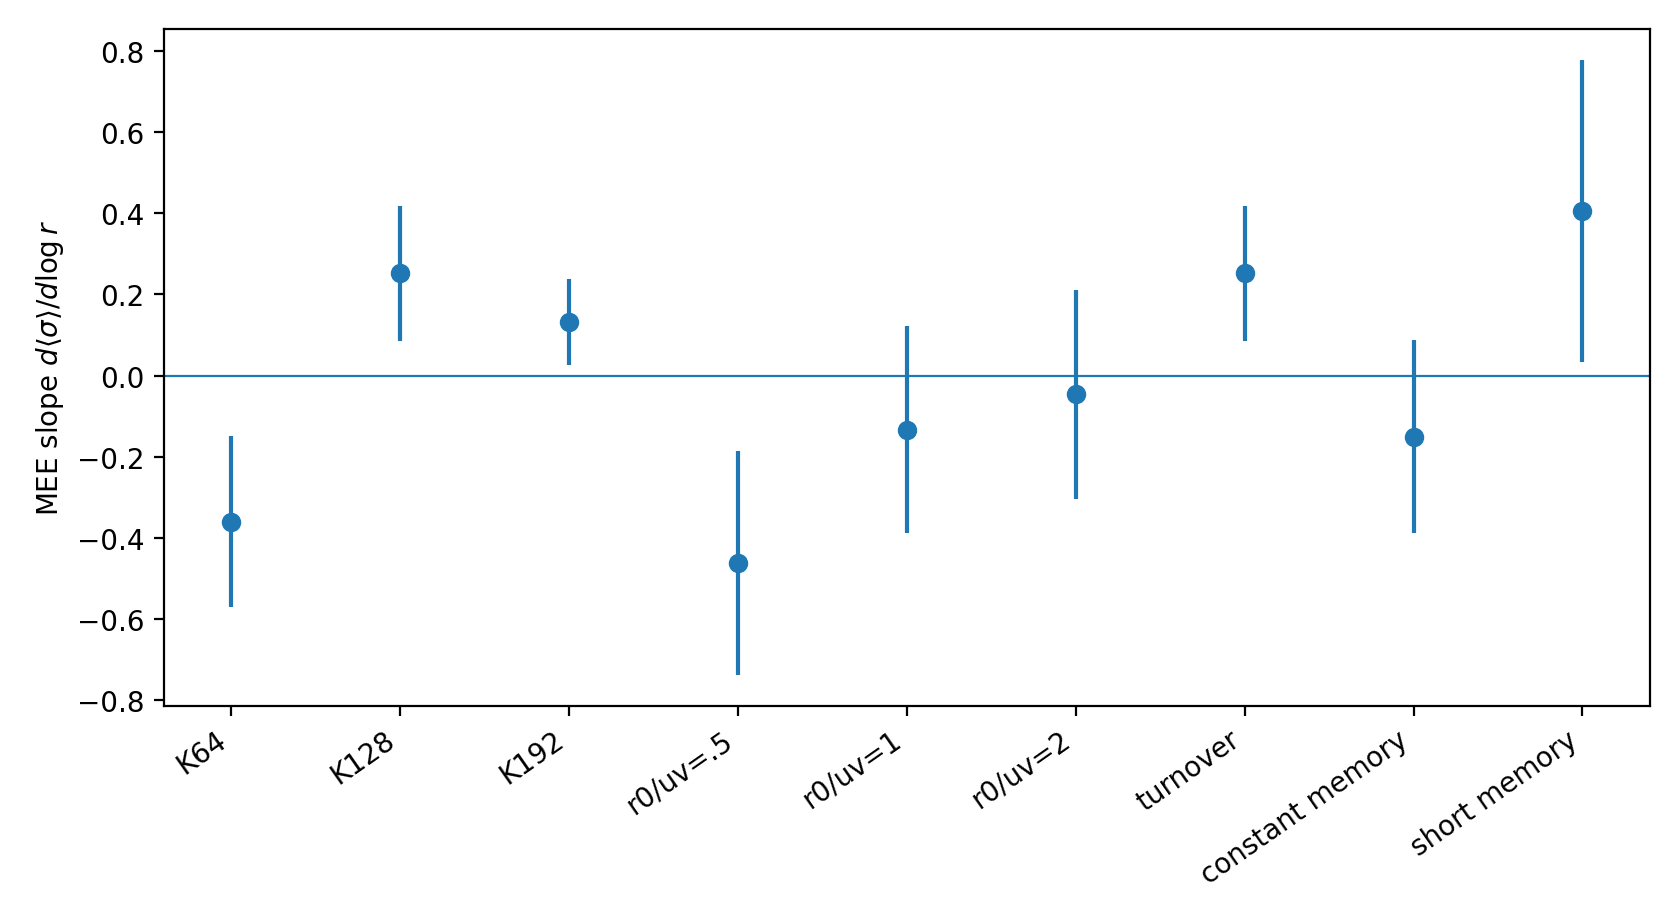

figS_particle_number.png


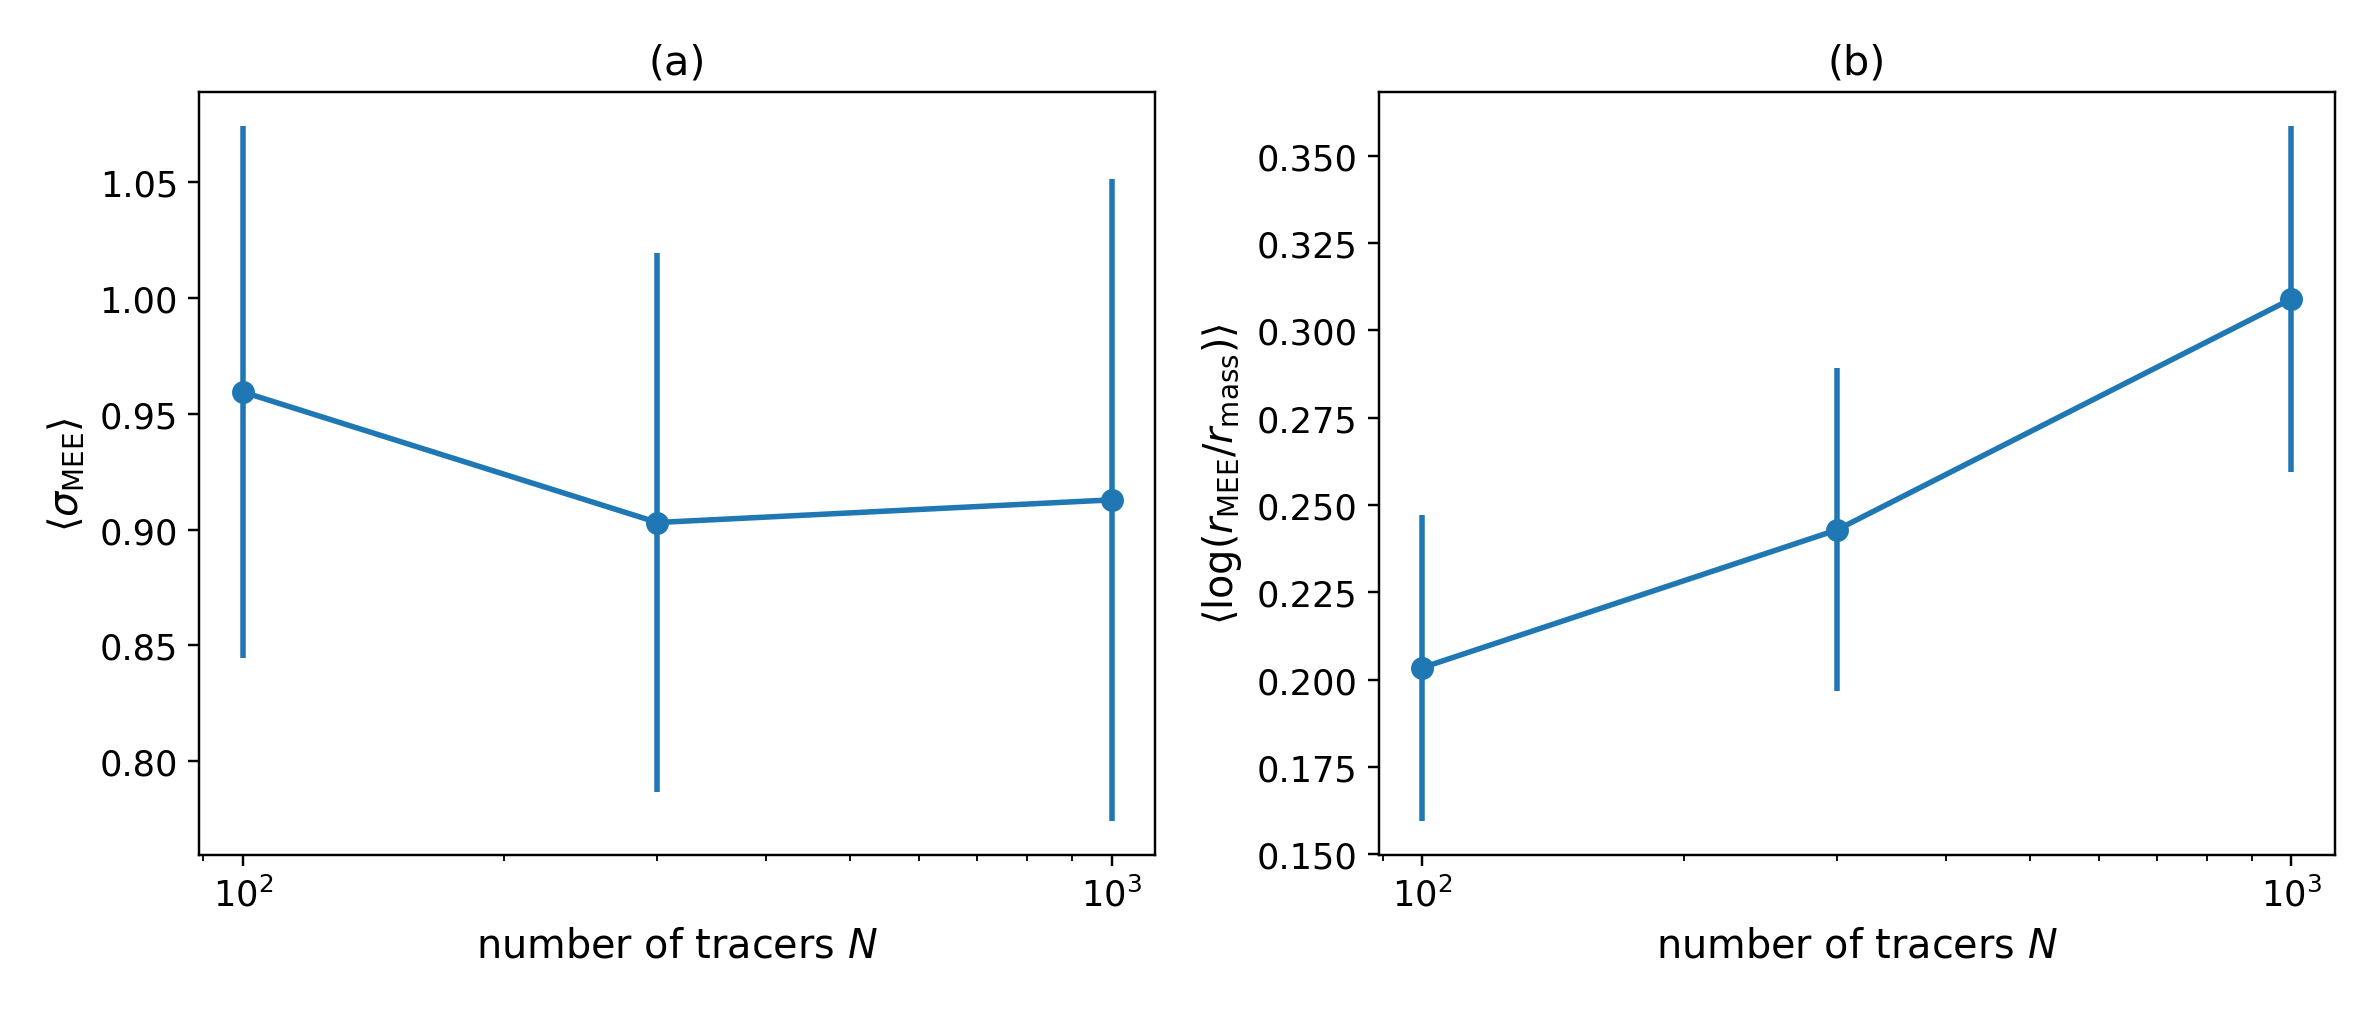

B2_roughness_delta_rho.png


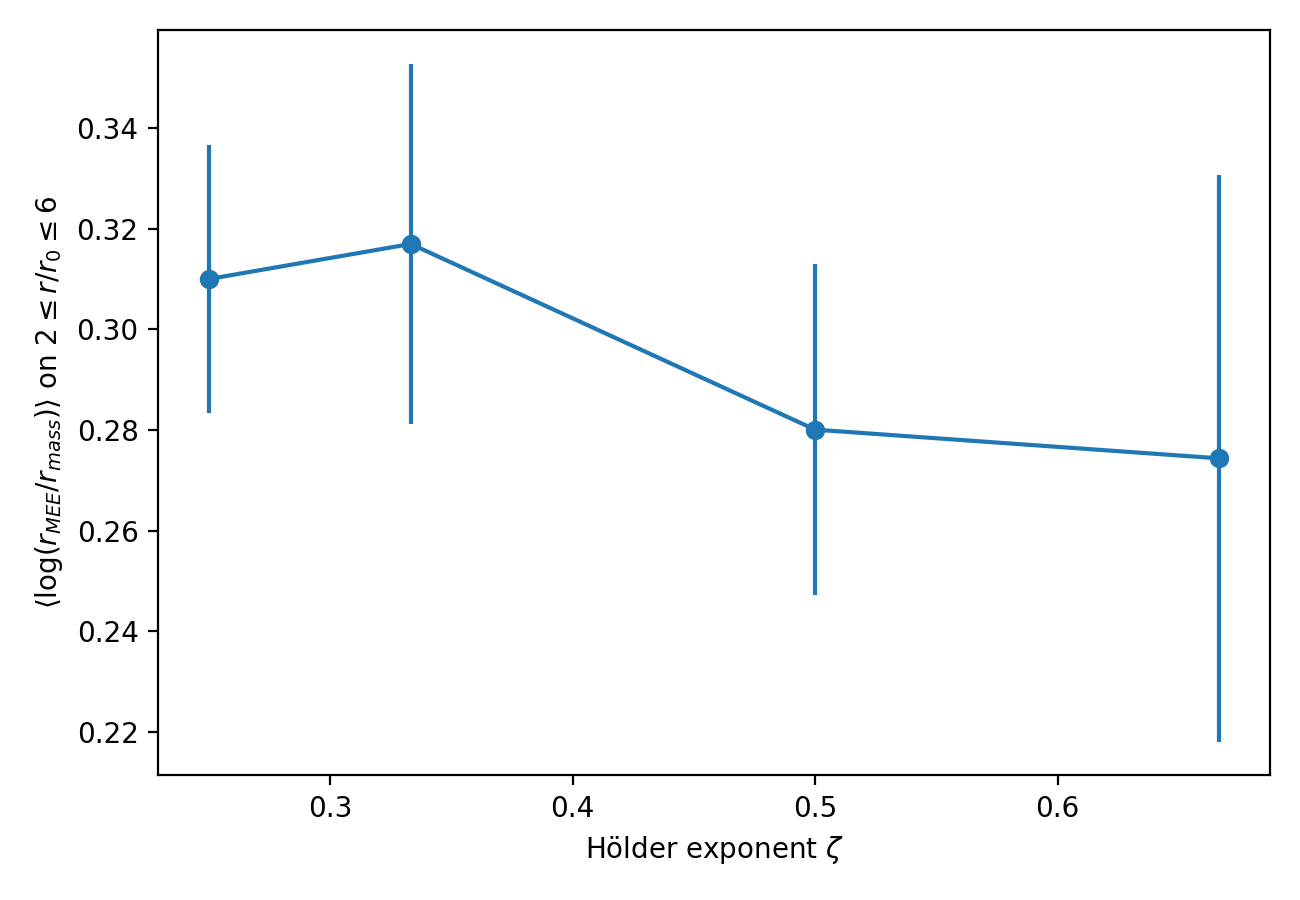

B4_tensor_corrector_scores.png


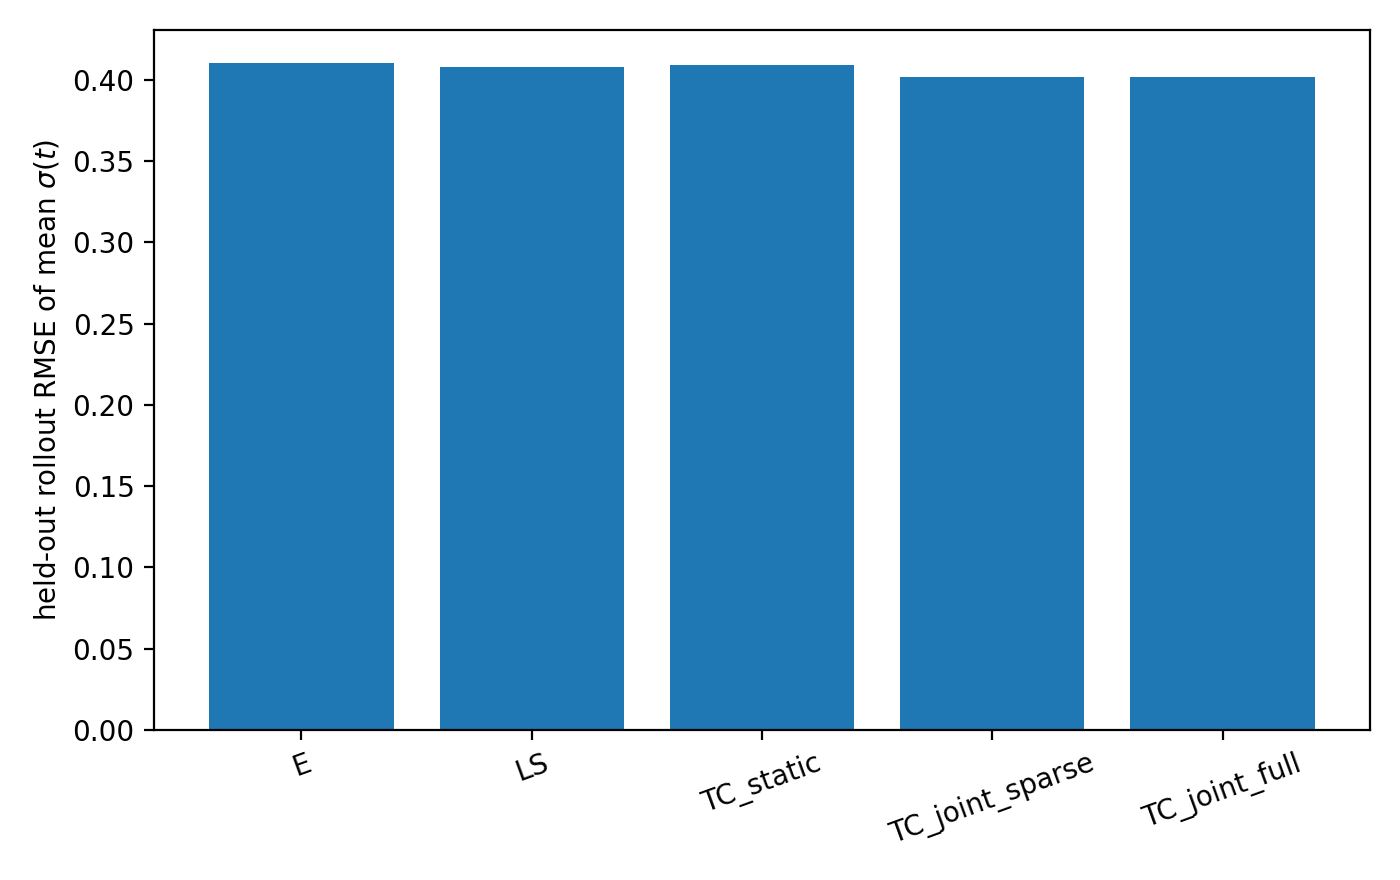

In [6]:
from IPython.display import Image, display
for name in ['B3_MEE_robustness.png','figS_particle_number.png','B2_roughness_delta_rho.png','B4_tensor_corrector_scores.png']:
    p = ROOT/'figures/controls'/name
    if p.exists():
        print(name)
        display(Image(filename=str(p), width=900))

The radial bulk-envelope gap is robust. Its trend with the Hölder exponent is suggestive but not statistically decisive, so the paper does not claim a monotone universal roughness law.